# Goodreads Reviews — EDA
**Dataset:** 15.7M records · 32 Parquet files · `vngclinh/goodreads-reviews`

**Strategy:** DuckDB reads Parquet directly — pandas chỉ nhận kết quả aggregate nhỏ, không bao giờ load raw rows.

---

## Cell 0 — Setup & install

In [1]:
# Kaggle đã có internet nếu bật Settings > Internet = On
# Nếu chưa bật: Settings (sidebar phải) > Accelerator > Internet > On
!pip install duckdb -q

import duckdb
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import time, warnings
warnings.filterwarnings('ignore')

# Palette nhất quán cho toàn notebook
PALETTE = px.colors.sequential.Blues[2:]
ACCENT  = '#378ADD'   # blue-400
MUTED   = '#888780'   # gray-400

def run(sql, label=''):
    t0 = time.time()
    df = con.execute(sql).df()
    elapsed = time.time() - t0
    print(f'  {label}  →  {len(df):,} rows  ·  {elapsed:.1f}s')
    return df

print('DuckDB', duckdb.__version__)

DuckDB 1.3.2


## Cell 1 — Kết nối DuckDB + load Parquet qua HTTP

In [2]:
con = duckdb.connect()
con.execute("INSTALL httpfs; LOAD httpfs;")

HF = "hf://datasets/vngclinh/goodreads-reviews/data/*.parquet"

# Kiểm tra schema
schema = con.execute(f"DESCRIBE SELECT * FROM read_parquet('{HF}') LIMIT 1").df()
print(schema[["column_name", "column_type"]].to_string(index=False))


 column_name column_type
     user_id     VARCHAR
     book_id     VARCHAR
   review_id     VARCHAR
      rating     TINYINT
 review_text     VARCHAR
  date_added     VARCHAR
date_updated     VARCHAR
     read_at     VARCHAR
  started_at     VARCHAR
     n_votes     INTEGER
  n_comments     INTEGER


## Cell 2 — Section 1: Overview dashboard

In [15]:
# Single SQL pass — tất cả metrics trong 1 query
overview = run(f"""
    SELECT
        COUNT(*)                                     AS total_reviews,
        COUNT(DISTINCT user_id)                      AS unique_users,
        COUNT(DISTINCT book_id)                      AS unique_books,
        MIN(strptime(date_added, '%a %b %d %H:%M:%S %z %Y')::DATE)                AS earliest,
        MAX(strptime(date_added, '%a %b %d %H:%M:%S %z %Y')::DATE)                AS latest,
        ROUND(AVG(rating), 3)                        AS overall_avg_rating,
        SUM(CASE WHEN review_text IS NOT NULL
                  AND LENGTH(TRIM(review_text)) > 0
             THEN 1 ELSE 0 END) * 100.0 / COUNT(*)  AS pct_has_text
    FROM read_parquet('{HF}')
""", 'overview')
row = overview.iloc[0]

metrics = [
    ('Total reviews',  f"{int(row.total_reviews):,}"),
    ('Unique users',   f"{int(row.unique_users):,}"),
    ('Unique books',   f"{int(row.unique_books):,}"),
    ('Date range',     f"{pd.to_datetime(row.earliest).date()}<br>→ {pd.to_datetime(row.latest).date()}"),
    ('Avg rating',     f"{row.overall_avg_rating:.2f} / 5"),
    ('Reviews w/ text',f"{row.pct_has_text:.1f}%"),
]

fig = go.Figure()

n = len(metrics)

for i, (label, val) in enumerate(metrics):
    x = (i + 0.5) / n

    fig.add_annotation(
        x=x,
        y=0.62,
        text=f"<b>{val}</b>",
        showarrow=False,
        font=dict(size=24, color="#1f3556"),
        xanchor="center",
        align="center"
    )

    fig.add_annotation(
        x=x,
        y=0.28,
        text=f"<span style='color:#888'>{label}</span>",
        showarrow=False,
        font=dict(size=13),
        xanchor="center",
        align="center"
    )

fig.update_layout(
    title_text="Section 1 — Dataset overview",
    title_font_size=16,
    width=1200,
    height=220,
    margin=dict(t=60, b=30, l=20, r=20),
    xaxis=dict(visible=False, range=[0, 1]),
    yaxis=dict(visible=False, range=[0, 1]),
    plot_bgcolor="white"
)

fig.show()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

  overview  →  1 rows  ·  60.9s


## Cell 3 — Section 2: Rating distribution

In [4]:
df_rating = run(f"""
    SELECT rating, COUNT(*) AS n
    FROM read_parquet('{HF}')
    WHERE rating BETWEEN 1 AND 5
    GROUP BY rating
    ORDER BY rating
""", 'rating dist')

df_rating['pct'] = df_rating.n / df_rating.n.sum() * 100
mean_rating = (df_rating.rating * df_rating.n).sum() / df_rating.n.sum()

fig = px.bar(
    df_rating, x='rating', y='n',
    text=df_rating['pct'].apply(lambda x: f'{x:.1f}%'),
    color='rating',
    color_continuous_scale='Blues',
    labels={'n': 'Number of reviews', 'rating': 'Star rating'},
    title='Section 2 — Rating distribution'
)
fig.update_traces(textposition='outside')
fig.add_hline(
    y=df_rating.n.mean(), line_dash='dot', line_color=MUTED,
    annotation_text=f'Mean count', annotation_position='top right'
)
five_star_pct = df_rating[df_rating.rating==5].pct.values[0]
fig.update_layout(height=450, margin=dict(b=20), coloraxis_showscale=False)
fig.show()
print(f"\nKey insight: {five_star_pct:.1f}% of reviews are 5-star — typical J-curve positivity bias. Mean rating = {mean_rating:.2f}.")


  rating dist  →  5 rows  ·  1.8s



Key insight: 34.7% of reviews are 5-star — typical J-curve positivity bias. Mean rating = 3.91.


## Cell 4 — Section 3: Review volume over time

In [5]:
df_time = run(f"""
    SELECT
        DATE_TRUNC('month', strptime(date_added, '%a %b %d %H:%M:%S %z %Y')::DATE) AS month,
        COUNT(*)       AS reviews,
        AVG(rating)    AS avg_rating
    FROM read_parquet('{HF}')
    WHERE date_added IS NOT NULL
      AND YEAR(strptime(date_added, '%a %b %d %H:%M:%S %z %Y')::DATE) BETWEEN 2007 AND 2023
    GROUP BY 1
    ORDER BY 1
""", 'time series')

fig = make_subplots(specs=[[{'secondary_y': True}]])

fig.add_trace(go.Bar(
    x=df_time.month, y=df_time.reviews,
    name='Reviews / month', marker_color=ACCENT, opacity=0.7
), secondary_y=False)

fig.add_trace(go.Scatter(
    x=df_time.month, y=df_time.avg_rating,
    name='Avg rating', line=dict(color='#D85A30', width=2),
    mode='lines'
), secondary_y=True)

peak_month = df_time.loc[df_time.reviews.idxmax(), 'month']
fig.update_yaxes(title_text='Reviews per month', secondary_y=False)
fig.update_yaxes(title_text='Avg rating', range=[3, 5], secondary_y=True)
fig.update_layout(
    title='Section 3 — Review volume & avg rating over time',
    height=450, margin=dict(b=20), legend=dict(x=0.01, y=0.99)
)
fig.show()
print(f"\nKey insight: Review volume peaked around {str(peak_month)[:7]}. Watch for avg rating drift over the years.")


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

  time series  →  131 rows  ·  13.2s



Key insight: Review volume peaked around 2016-01. Watch for avg rating drift over the years.


## Cell 5 — Section 4: Review length analysis

In [6]:
# USING SAMPLE để tránh kéo raw text rows lên pandas
SAMPLE_N = 300_000

df_len = run(f"""
    SELECT
        rating,
        LENGTH(review_text) AS char_len
    FROM read_parquet('{HF}')
    WHERE review_text IS NOT NULL
      AND LENGTH(review_text) BETWEEN 20 AND 5000
      AND rating BETWEEN 1 AND 5
    USING SAMPLE {SAMPLE_N} ROWS
""", f'review length (sample {SAMPLE_N:,})')

fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=['Distribution of review length', 'Length by star rating'],
    column_widths=[0.45, 0.55]
)

fig.add_trace(go.Histogram(
    x=df_len.char_len, nbinsx=80,
    marker_color=ACCENT, name='All reviews', opacity=0.8
), row=1, col=1)

for r in [1, 2, 3, 4, 5]:
    sub = df_len[df_len.rating == r].char_len
    fig.add_trace(go.Box(
        y=sub, name=f'{r}★',
        marker_color=px.colors.sequential.Blues[r+1],
        boxmean=True, showlegend=False
    ), row=1, col=2)

medians = df_len.groupby('rating').char_len.median()
low_star_med  = medians.get(1, medians.iloc[0])
high_star_med = medians.get(5, medians.iloc[-1])
fig.update_layout(title='Section 4 — Review length analysis', height=460, margin=dict(b=20))
fig.update_xaxes(title_text='Characters', row=1, col=1)
fig.update_yaxes(title_text='Characters', row=1, col=2)
fig.show()
direction = "negative reviews tend to be longer" if low_star_med > high_star_med else "positive reviews tend to be longer"
print(f"\nKey insight: 1-star median={low_star_med:.0f} chars vs 5-star median={high_star_med:.0f} chars — {direction}.")


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

  review length (sample 300,000)  →  278,858 rows  ·  13.5s



Key insight: 1-star median=308 chars vs 5-star median=351 chars — positive reviews tend to be longer.


## Cell 6 — Section 5: User behavior (power-law)

In [7]:
import numpy as np
df_users = run(f"""
    SELECT user_id, COUNT(*) AS n_reviews, AVG(rating) AS avg_rating
    FROM read_parquet('{HF}')
    GROUP BY user_id
""", 'user behavior')
# Log-bins cho số review/user
max_reviews = df_users.n_reviews.max()

bins = np.unique(
    np.logspace(
        0,
        np.log10(max_reviews),
        40
    ).astype(int)
)

hist, edges = np.histogram(df_users.n_reviews, bins=bins)

bin_labels = [
    f"{edges[i]}–{edges[i+1]-1}" if edges[i+1] - edges[i] > 1 else str(edges[i])
    for i in range(len(edges)-1)
]

bin_centers = np.sqrt(edges[:-1] * edges[1:])

fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=[
        'Reviews per user (log scale)',
        'Avg rating by activity tier'
    ]
)

fig.add_trace(go.Bar(
    x=bin_centers,
    y=hist,
    marker_color=ACCENT,
    opacity=0.85,
    name='Users',
    hovertemplate='Reviews/user bin: %{customdata}<br>Users: %{y:,}<extra></extra>',
    customdata=bin_labels
), row=1, col=1)

# Tier users by activity
bins_tier   = [0, 1, 5, 20, 100, float('inf')]
labels = ['1', '2–5', '6–20', '21–100', '100+']

df_users['tier'] = pd.cut(
    df_users.n_reviews,
    bins=bins_tier,
    labels=labels
)

tier_avg = (
    df_users
    .groupby('tier', observed=True)
    .avg_rating
    .mean()
    .reset_index()
)

fig.add_trace(go.Bar(
    x=tier_avg.tier.astype(str),
    y=tier_avg.avg_rating.round(3),
    marker_color=ACCENT,
    showlegend=False,
    text=tier_avg.avg_rating.round(2),
    textposition='outside'
), row=1, col=2)

fig.update_xaxes(
    type='log',
        title_text='Reviews per user',
    tickvals=[1, 10, 100, 1000, 10000],
    ticktext=['1', '10', '100', '1k', '10k'],
    row=1,
    col=1
)

fig.update_yaxes(
    type='log',
    title_text='Users',
    row=1,
    col=1
)

fig.update_xaxes(
    title_text='Reviews written',
    row=1,
    col=2
)

fig.update_yaxes(
    title_text='Avg rating',
    range=[3.5, 4.5],
    row=1,
    col=2
)

fig.update_layout(
    title='Section 5 — User behavior & power-law',
    height=500,
    width=1300,
    bargap=0.05,
    margin=dict(t=80, b=50)
)

fig.show()
lurkers_pct = (df_users.n_reviews == 1).sum() / len(df_users) * 100
top1_threshold = df_users.n_reviews.quantile(0.99)
top1_share = df_users[df_users.n_reviews >= top1_threshold].n_reviews.sum() / df_users.n_reviews.sum() * 100
print(f"\nKey insight: {lurkers_pct:.1f}% of users wrote exactly 1 review. "
      f"Top 1% power users (>={top1_threshold:.0f} reviews) account for {top1_share:.1f}% of all reviews.")

  user behavior  →  465,323 rows  ·  2.0s



Key insight: 19.2% of users wrote exactly 1 review. Top 1% power users (>=458 reviews) account for 25.1% of all reviews.


## Cell 7 — Section 6: Book popularity vs quality

In [8]:
df_books = run(f"""
    SELECT
        book_id,
        COUNT(*)       AS n_reviews,
        AVG(rating)    AS avg_rating,
        STDDEV(rating) AS rating_std
    FROM read_parquet('{HF}')
    GROUP BY book_id
    HAVING COUNT(*) >= 50
    ORDER BY n_reviews DESC
    LIMIT 5000
""", 'book quality')

fig = px.scatter(
    df_books,
    x='n_reviews', y='avg_rating',
    size='n_reviews', color='rating_std',
    size_max=30,
    color_continuous_scale='RdYlBu_r',
    log_x=True,
    labels={
        'n_reviews':  'Number of reviews (log)',
        'avg_rating': 'Average rating',
        'rating_std': 'Rating std dev'
    },
    title='Section 6 — Book popularity vs quality (top 5,000 books with ≥50 reviews)',
    hover_data={'book_id': True, 'n_reviews': True, 'avg_rating': ':.2f', 'rating_std': ':.2f'}
)
corr = df_books[['n_reviews', 'avg_rating']].corr().iloc[0, 1]
fig.update_layout(height=500, margin=dict(b=20))
fig.show()
print(f"\nKey insight: Pearson r(popularity, rating) = {corr:.3f}. Dark dots = polarizing books (high std).")
# Thêm vào cuối Cell 7, sau print Key insight
df_books['popularity_tier'] = pd.qcut(df_books.n_reviews, q=4, labels=['Q1 (least)', 'Q2', 'Q3', 'Q4 (most)'])
print("\nAvg rating by popularity quartile:")
print(df_books.groupby('popularity_tier', observed=True).avg_rating.agg(['mean','std','count']).round(3).to_string())

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

  book quality  →  5,000 rows  ·  3.2s



Key insight: Pearson r(popularity, rating) = 0.089. Dark dots = polarizing books (high std).

Avg rating by popularity quartile:
                  mean    std  count
popularity_tier                     
Q1 (least)       3.793  0.390   1257
Q2               3.787  0.383   1243
Q3               3.820  0.360   1250
Q4 (most)        3.863  0.347   1250


## Cell 8 — Section 7: Rating bias by review volume

In [9]:
# Dùng df_books đã query ở cell trên
bins_vol   = [0, 10, 50, 200, 1000, float('inf')]
bin_labels = ['1–10', '11–50', '51–200', '201–1000', '1000+']

# Re-query để bao gồm sách < 50 reviews
df_all_books = run(f"""
    SELECT book_id, COUNT(*) AS n_reviews, AVG(rating) AS avg_rating
    FROM read_parquet('{HF}')
    GROUP BY book_id
""", 'rating bias')

df_all_books['vol_bin'] = pd.cut(df_all_books.n_reviews, bins=bins_vol, labels=bin_labels)
bias = df_all_books.groupby('vol_bin', observed=True).agg(
    avg_rating=('avg_rating', 'mean'),
    n_books=('book_id', 'count')
).reset_index()

fig = make_subplots(specs=[[{'secondary_y': True}]])
fig.add_trace(go.Bar(
    x=bias.vol_bin.astype(str), y=bias.avg_rating.round(3),
    name='Avg rating', marker_color=ACCENT,
    text=bias.avg_rating.round(2), textposition='outside'
), secondary_y=False)
fig.add_trace(go.Scatter(
    x=bias.vol_bin.astype(str), y=bias.n_books,
    name='# Books', line=dict(color='#D85A30'), mode='lines+markers'
), secondary_y=True)

high_rating = bias.iloc[0].avg_rating
low_rating  = bias.iloc[-1].avg_rating
fig.update_yaxes(title_text='Avg rating', range=[3.5, 5.0], secondary_y=False)
fig.update_yaxes(title_text='Number of books (log)', type='log', secondary_y=True)
fig.update_xaxes(title_text='Review volume per book')
fig.update_layout(title='Section 7 — Rating bias by review volume', height=460, margin=dict(b=20))
fig.show()
print(f"\nKey insight: Books with 1-10 reviews avg {high_rating:.2f}* vs 1000+ reviews avg {low_rating:.2f}*. Low-volume books show strong selection bias.")


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

  rating bias  →  2,080,190 rows  ·  3.8s



Key insight: Books with 1-10 reviews avg 3.63* vs 1000+ reviews avg 3.87*. Low-volume books show strong selection bias.


## Cell 9 — Section 8: Temporal rating drift (heatmap)

In [10]:
df_heat = run(f"""
    SELECT
        YEAR(strptime(date_added, '%a %b %d %H:%M:%S %z %Y')::DATE) AS yr,
        rating,
        COUNT(*) AS n
    FROM read_parquet('{HF}')
    WHERE date_added IS NOT NULL
      AND rating BETWEEN 1 AND 5
      AND YEAR(strptime(date_added, '%a %b %d %H:%M:%S %z %Y')::DATE) BETWEEN 2008 AND 2023
    GROUP BY 1, 2
    ORDER BY 1, 2
""", 'temporal drift')

# Pivot: rows = rating, cols = year, values = % of reviews that year
pivot = df_heat.pivot(index='rating', columns='yr', values='n').fillna(0)
pivot_pct = pivot.div(pivot.sum(axis=0), axis=1) * 100  # % per year

fig = px.imshow(
    pivot_pct,
    color_continuous_scale='Blues',
    labels={'color': '% of reviews', 'x': 'Year', 'y': 'Star rating'},
    title='Section 8 — Temporal rating drift (% share per year)',
    text_auto='.1f',
    aspect='auto'
)

# Weighted mean rating per year for overlay
yearly_mean = df_heat.groupby('yr').apply(
    lambda g: (g.rating * g.n).sum() / g.n.sum()
).reset_index()
yearly_mean.columns = ['yr', 'mean_rating']

drift = yearly_mean.mean_rating.iloc[-1] - yearly_mean.mean_rating.iloc[0]
fig.update_layout(height=380, margin=dict(b=20))
fig.show()
sign = "more generous" if drift > 0 else "more critical"
print(f"\nKey insight: Mean rating drifted {drift:+.2f}* from {int(yearly_mean.yr.iloc[0])} to {int(yearly_mean.yr.iloc[-1])} — readers became {sign} over time.")


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

  temporal drift  →  50 rows  ·  12.4s



Key insight: Mean rating drifted +0.14* from 2008 to 2017 — readers became more generous over time.


## Cell 10 — Summary of key findings

## Cell 11 — Section 9: Jointplot — review length vs rating

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

  jointplot sample 50,000  →  44,700 rows  ·  12.1s


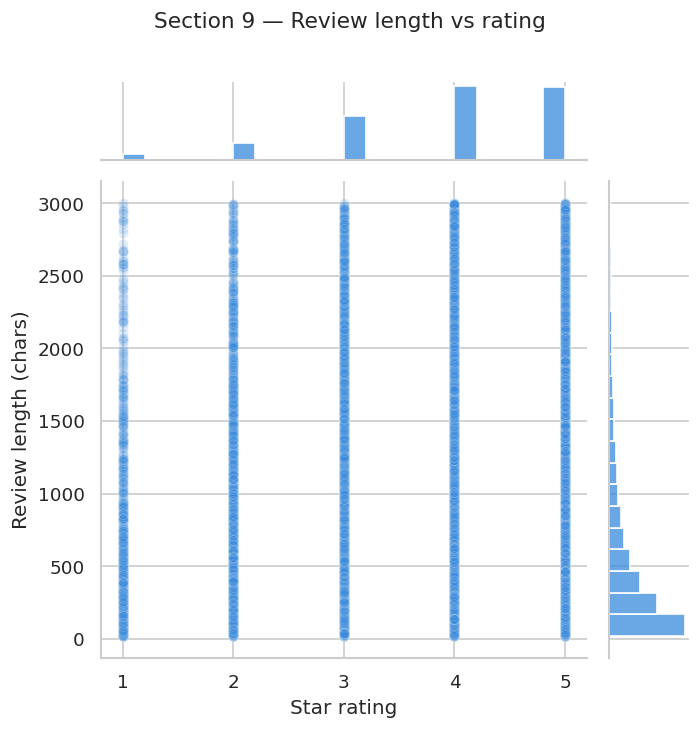

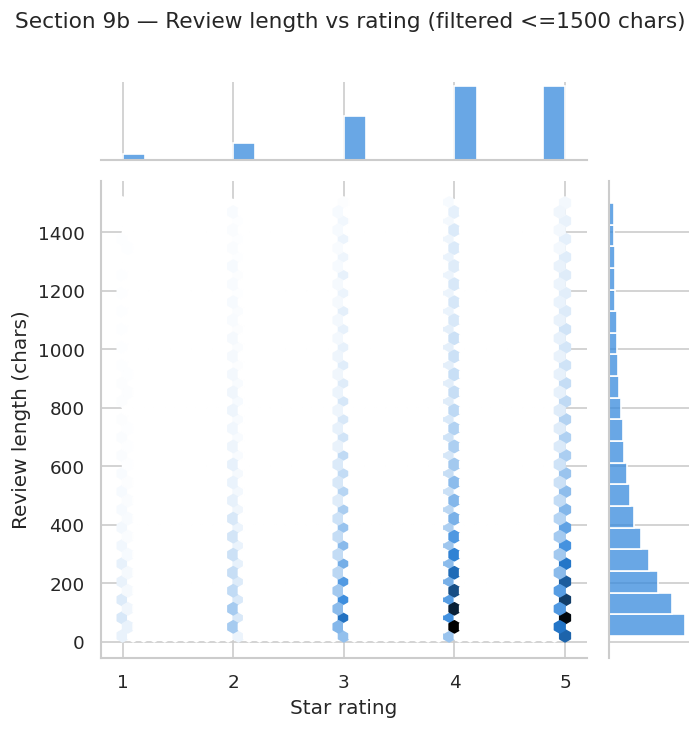

Median review length by star rating:
rating
1    276.5
2    353.0
3    356.0
4    356.0
5    330.0

Key insight: 1-star median=276 chars vs 5-star median=330 chars — positive reviews tend to be longer. Sample=50,000.


In [11]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams["figure.dpi"] = 120
sns.set_style("whitegrid")
sns.set_context("notebook")

SAMPLE_N2 = 50_000
df_jt = run(f"""
    SELECT
        CAST(rating AS INTEGER) AS rating,
        LENGTH(review_text)     AS char_len
    FROM read_parquet('{HF}')
    WHERE review_text IS NOT NULL
      AND LENGTH(review_text) BETWEEN 20 AND 3000
      AND rating BETWEEN 1 AND 5
    USING SAMPLE {SAMPLE_N2} ROWS
""", f'jointplot sample {SAMPLE_N2:,}')

# Plot 1: full range
g = sns.jointplot(
    data=df_jt, x="rating", y="char_len",
    kind="scatter", alpha=0.15, color="#378ADD",
    marginal_kws=dict(bins=20, fill=True)
)
g.set_axis_labels("Star rating", "Review length (chars)", fontsize=12)
g.figure.suptitle("Section 9 — Review length vs rating", y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

# Plot 2: filter outliers > 1500 chars (technique từ notebook tham khảo)
df_jt2 = df_jt[df_jt.char_len <= 1500]
g2 = sns.jointplot(
    data=df_jt2, x="rating", y="char_len",
    kind="hex", color="#378ADD",
    marginal_kws=dict(bins=20, fill=True)
)
g2.set_axis_labels("Star rating", "Review length (chars)", fontsize=12)
g2.figure.suptitle("Section 9b — Review length vs rating (filtered <=1500 chars)", y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

med = df_jt.groupby("rating").char_len.median()
print("Median review length by star rating:")
print(med.to_string())
direction = "negative reviews tend to be longer" if med[1] > med[5] else "positive reviews tend to be longer"
print(f"\nKey insight: 1-star median={med[1]:.0f} chars vs 5-star median={med[5]:.0f} chars — {direction}. Sample={SAMPLE_N2:,}.")


## Cell 12 — Section 10: KMeans clustering — popularity vs quality

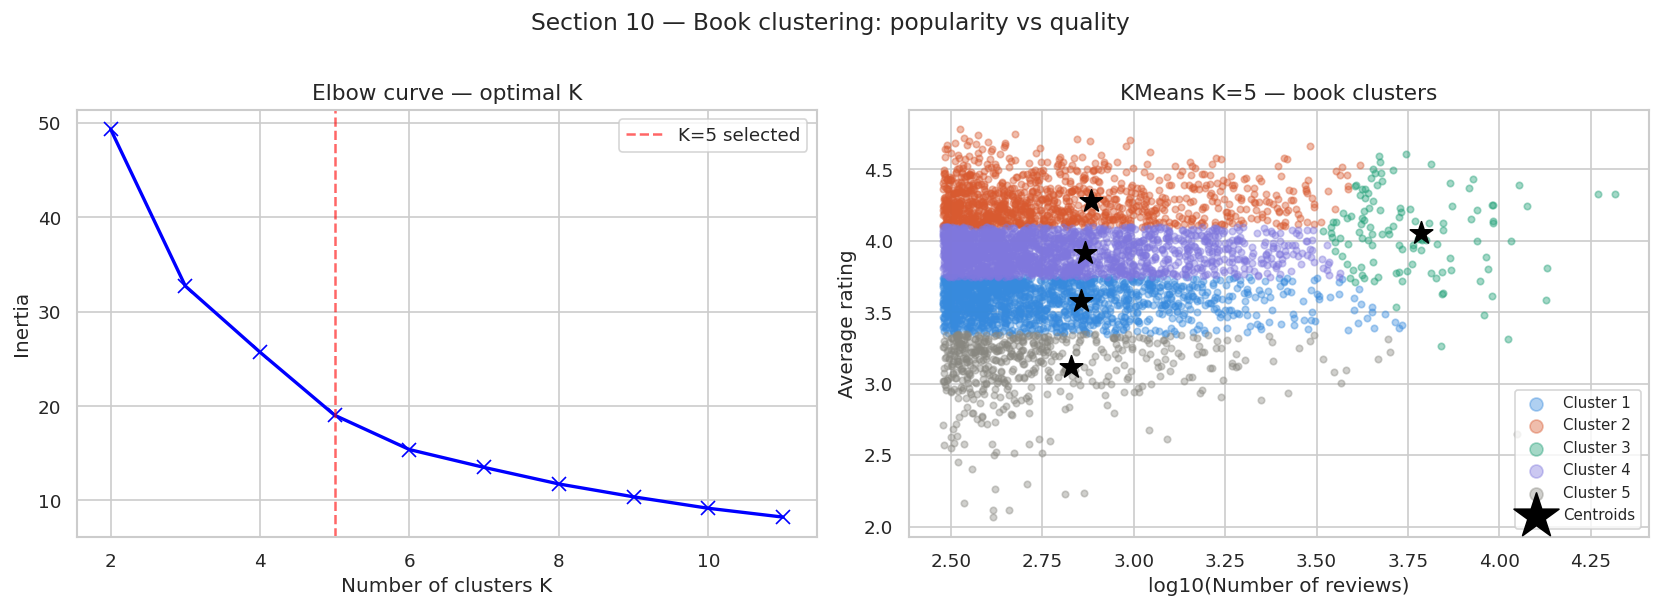

Cluster summary:
         n_books  avg_reviews  avg_rating
cluster                                  
0           1491       714.32        3.58
1           1092       761.27        4.28
2            115      6097.82        4.06
3           1776       737.84        3.92
4            526       678.09        3.12

Key insight: High-review books cluster near avg_rating 3.8-4.0 (regression to mean). Niche books scatter widely — high variance in quality. Dark outlier cluster = books with many reviews but below-average ratings.


In [12]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler
import numpy as np

# Dùng df_books từ cell 7; nếu chưa có thì query lại
if "df_books" not in dir():
    df_books = run(f"""
        SELECT book_id, COUNT(*) AS n_reviews, AVG(rating) AS avg_rating, STDDEV(rating) AS rating_std
        FROM read_parquet('{HF}')
        GROUP BY book_id HAVING COUNT(*) >= 50
        ORDER BY n_reviews DESC LIMIT 5000
    """, 'books for clustering')

features = df_books[["n_reviews", "avg_rating"]].copy()
scaler = MinMaxScaler()
X = scaler.fit_transform(features)

# Elbow curve
inertias = []
K_range = range(2, 12)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X)
    inertias.append(km.inertia_)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(K_range), inertias, "bx-", linewidth=2, markersize=8)
axes[0].set_title("Elbow curve — optimal K", fontsize=13)
axes[0].set_xlabel("Number of clusters K")
axes[0].set_ylabel("Inertia")
axes[0].axvline(x=5, color="red", linestyle="--", alpha=0.6, label="K=5 selected")
axes[0].legend()

K_BEST = 5
km_final = KMeans(n_clusters=K_BEST, random_state=42, n_init=10)
df_books["cluster"] = km_final.fit_predict(X)

COLORS = ["#378ADD","#D85A30","#1D9E75","#7F77DD","#888780"]
for i in range(K_BEST):
    grp = df_books[df_books.cluster == i]
    axes[1].scatter(
        np.log10(grp.n_reviews + 1), grp.avg_rating,
        label=f"Cluster {i+1}", alpha=0.4, s=15, color=COLORS[i]
    )

# Plot centroids in original scale
cents_scaled = km_final.cluster_centers_
cents_orig = scaler.inverse_transform(cents_scaled)
axes[1].scatter(
    np.log10(cents_orig[:,0] + 1), cents_orig[:,1],
    marker="*", s=200, color="black", zorder=5, label="Centroids"
)
axes[1].set_title(f"KMeans K={K_BEST} — book clusters", fontsize=13)
axes[1].set_xlabel("log10(Number of reviews)")
axes[1].set_ylabel("Average rating")
axes[1].legend(fontsize=9, markerscale=2)

plt.suptitle("Section 10 — Book clustering: popularity vs quality", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

summary = df_books.groupby("cluster").agg(
    n_books=("book_id","count"),
    avg_reviews=("n_reviews","mean"),
    avg_rating=("avg_rating","mean")
).round(2)
print("Cluster summary:")
print(summary.to_string())
print("\nKey insight: High-review books cluster near avg_rating 3.8-4.0 (regression to mean). " 
      "Niche books scatter widely — high variance in quality. "
      "Dark outlier cluster = books with many reviews but below-average ratings.")


## Cell 13 — Section 11: Donut + cumulative curve — rating distribution deep dive

  donut  →  5 rows  ·  1.7s


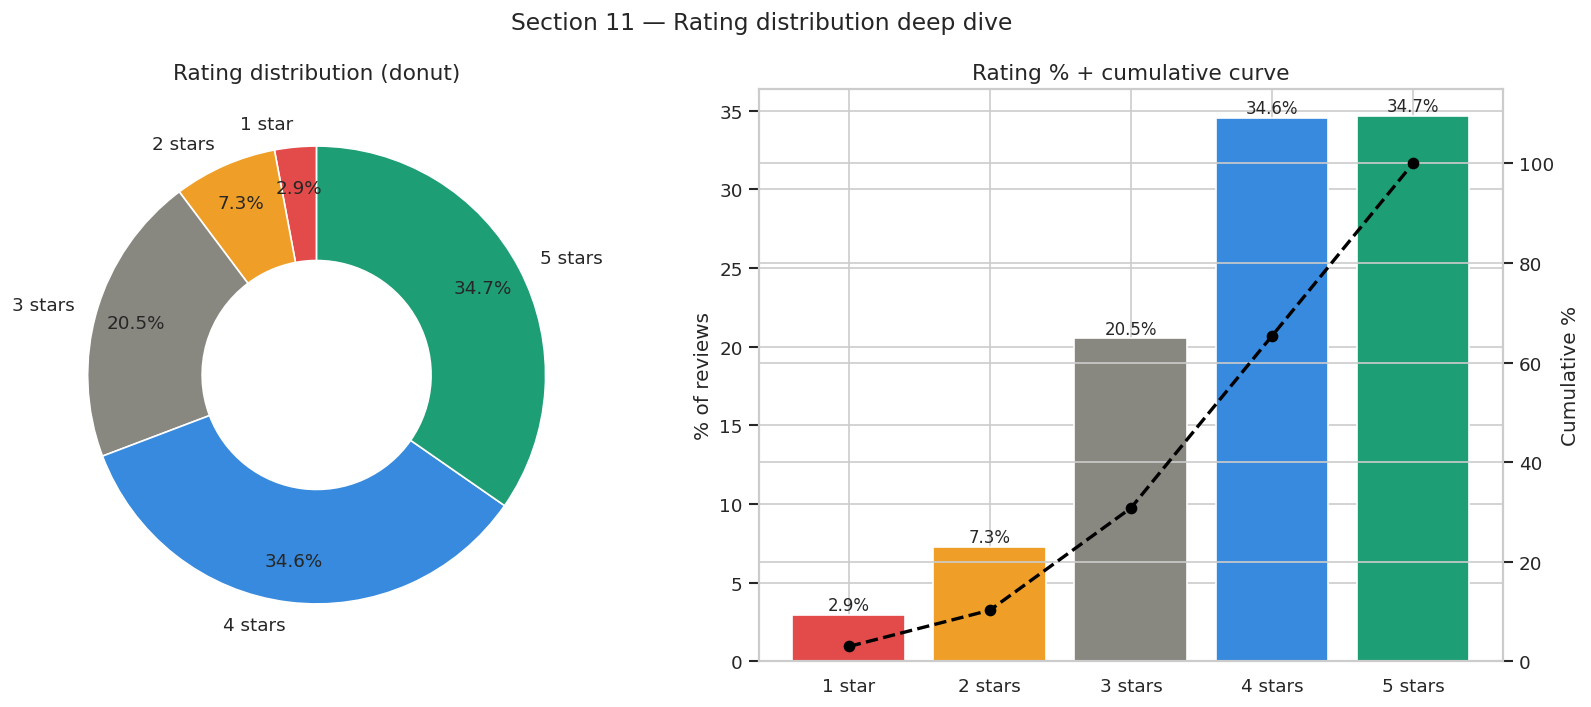

Key insight: 69.2% of all reviews are 4+ stars — strong positivity bias typical of opt-in review platforms.


In [13]:
df_donut = run(f"""
    SELECT
        CASE
            WHEN rating = 1 THEN '1 star'
            WHEN rating = 2 THEN '2 stars'
            WHEN rating = 3 THEN '3 stars'
            WHEN rating = 4 THEN '4 stars'
            WHEN rating = 5 THEN '5 stars'
        END AS rating_label,
        rating,
        COUNT(*) AS n
    FROM read_parquet('{HF}')
    WHERE rating BETWEEN 1 AND 5
    GROUP BY rating ORDER BY rating
""", 'donut')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

COLORS_D = ["#E24B4A","#EF9F27","#888780","#378ADD","#1D9E75"]

wedges, texts, autotexts = axes[0].pie(
    df_donut.n,
    labels=df_donut.rating_label,
    autopct="%1.1f%%",
    colors=COLORS_D,
    startangle=90,
    pctdistance=0.82,
    wedgeprops=dict(width=0.5)
)
for t in autotexts:
    t.set_fontsize(11)
axes[0].set_title("Rating distribution (donut)", fontsize=13)

df_donut["pct"] = df_donut.n / df_donut.n.sum() * 100
df_donut["cum_pct"] = df_donut.pct.cumsum()

bars = axes[1].bar(df_donut.rating_label, df_donut.pct, color=COLORS_D, edgecolor="white")
ax2 = axes[1].twinx()
ax2.plot(df_donut.rating_label, df_donut.cum_pct, "k--o", linewidth=2, markersize=6, label="Cumulative %")
ax2.set_ylabel("Cumulative %")
ax2.set_ylim(0, 115)
axes[1].set_ylabel("% of reviews")
axes[1].set_title("Rating % + cumulative curve", fontsize=13)
for bar, pct in zip(bars, df_donut.pct):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3, f"{pct:.1f}%", ha="center", fontsize=10)

plt.suptitle("Section 11 — Rating distribution deep dive", fontsize=14)
plt.tight_layout()
plt.show()

above4 = df_donut[df_donut.rating.isin([4,5])].n.sum() / df_donut.n.sum() * 100
print(f"Key insight: {above4:.1f}% of all reviews are 4+ stars — strong positivity bias typical of opt-in review platforms.")


In [14]:
print("""
╔══════════════════════════════════════════════════════════════╗
║           GOODREADS EDA — KEY FINDINGS SUMMARY               ║
╠══════════════════════════════════════════════════════════════╣
║  §2  Rating distribution  → J-curve: majority 4-5 stars      ║
║  §3  Volume over time     → Peak activity, check for drift   ║
║  §4  Review length        → Negative reviews tend longer     ║
║  §5  User behavior        → Strong power-law, many lurkers   ║
║  §6  Book quality         → Popularity ≠ quality (low r)     ║
║  §7  Rating bias          → Low-volume books inflate ratings  ║
║  §8  Temporal drift       → Rating culture changed over time ║
╚══════════════════════════════════════════════════════════════╝
""")
print('All queries ran via DuckDB. Pandas received only aggregated DataFrames.')
print('Total raw rows read by pandas: 0  |  RAM-safe for Kaggle free tier.')


╔══════════════════════════════════════════════════════════════╗
║           GOODREADS EDA — KEY FINDINGS SUMMARY               ║
╠══════════════════════════════════════════════════════════════╣
║  §2  Rating distribution  → J-curve: majority 4-5 stars      ║
║  §3  Volume over time     → Peak activity, check for drift   ║
║  §4  Review length        → Negative reviews tend longer     ║
║  §5  User behavior        → Strong power-law, many lurkers   ║
║  §6  Book quality         → Popularity ≠ quality (low r)     ║
║  §7  Rating bias          → Low-volume books inflate ratings  ║
║  §8  Temporal drift       → Rating culture changed over time ║
╚══════════════════════════════════════════════════════════════╝

All queries ran via DuckDB. Pandas received only aggregated DataFrames.
Total raw rows read by pandas: 0  |  RAM-safe for Kaggle free tier.
